# 1. What did the ERP actually send, and does the dashboard's Rs 2.1 crore follow from it?

**Week 1, Wednesday. Chapter 1 of 6.** Tuesday's analysis found that orders per customer in Retail-Plus, Kalpa's paid membership tier,
fell 49 percent from Q1 to Q2, from 2.32 to 1.18. It was measured on an export from the ERP, the
enterprise resource planning system Finance books orders in, exactly as the export arrived. This
chapter profiles what arrived, counting what every field holds, before anyone totals it: the orders
CSV, and beside it the app's JSON feed, a file of orders written as JSON records.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Anand Iyer, the finance controller, decides whether Finance acts on Tuesday's drop at all, and his
analyst ties out every figure tonight: she matches each one to the books, Finance's own record of
Q1 at Rs 1,90,00,000 to the rupee, line by line, so a rupee's difference is a finding. A wrong
count costs the most of the day, since every later number stands on it: a note that calls the
dashboard right when it is not makes the analyst discount everything the team sends, and
Marketing loses a month.

**The questions on the way.**

1. How could we learn what arrived, and what would each way cost on 201 rows?
2. What does the file hold, field by field?
3. Which Q2 order is the largest?
4. Does the dashboard's Rs 2.1 crore follow from this file?
5. What can the app's JSON feed tell us?
6. Do two other methods reach the same counts?

**The need.** The metric is Q1 revenue, which here is booked value: every order at the price
charged, whatever its status, which is what revenue means in every Q1 and Q2 figure today. The
dashboard's figure and the books' figure disagree by about Rs 20 lakh. The dashboard reads the
ERP's orders CSV, and the ERP team's note says the file was stitched from two extracts, two
separate pulls of rows out of the ERP, during the Q1 migration, the move of the order data from
one system to another. Before anyone totals anything, the team needs four counts from the export:
how many records arrived, how many are complete, how many read as numbers and how many are
distinct.

**Who else faces it.** Target Canada launched in March 2013, lost almost a billion dollars in its
first year and in January 2015 announced it would close all 133 stores (CBC News, 15 January 2015,
checked 30 Sep 2026). Salsify's summary of the Canadian Business investigation puts the accuracy of
the product data in its new system at about 30 percent, against 98 to 99 percent in the US (checked
30 Sep 2026). Kalpa's export was also stitched together during a system change, so its rows need
counting before anyone trusts a total.

For more depth on the business behind these numbers, the retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, covers how the business makes money
in section 3, who decides what in section 4, and in section 5 the revenue tree, which writes revenue as
customers x orders per customer x revenue per order.

**Setup.** The cell finds the shared helper `kit` and defines the day's first tools. `read_orders()`
reads an export into dictionaries, one per row, each mapping a field's name to its value, and
remembers the file line each row came from; `convert()` turns an amount into rupees or says why it
could not; and `profile()` counts, for each field, the values present, the values that convert to
a number where the field holds numbers, and the distinct values.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        present = [r.get(f, "") for r in rows if r.get(f, "") not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

raw = read_orders()
print(len(raw), "rows read from", ORDERS_CSV.name)

201 rows read from C2_W01_D03_orders_STUDENT.csv


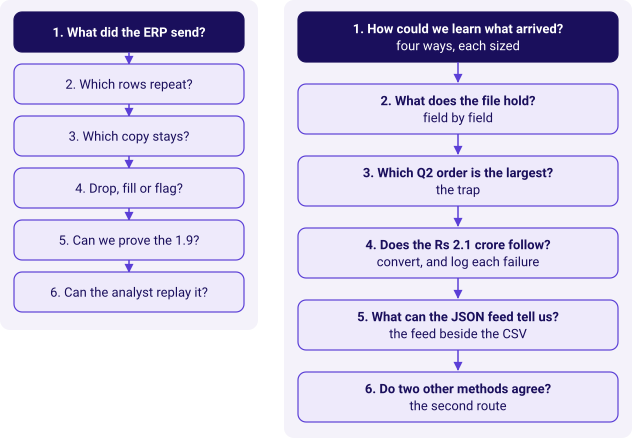

In [2]:
kit.side_by_side(
    kit.ladder(["What did the ERP send?", "Which rows repeat?", "Which copy stays?", "Drop, fill or flag?", "Can we prove the 1.9?", "Can the analyst replay it?"], lit=0, show=False),
    kit.vflow(["1. How could we learn what arrived?\nfour ways, each sized", "2. What does the file hold?\nfield by field", "3. Which Q2 order is the largest?\nthe trap", "4. Does the Rs 2.1 crore follow?\nconvert, and log each failure", "5. What can the JSON feed tell us?\nthe feed beside the CSV", "6. Do two other methods agree?\nthe second route"], lit=0, show=False),
)

## 1. How could we learn what arrived, and what would each way cost on 201 rows?

A team could find out what the ERP sent in four ways, and the cell below sizes each one on this file.

| Option | What it does | What it can miss |
|---|---|---|
| a) Total it and compare | Sum the amounts, set the sum beside Rs 1.9 crore | Why the two differ, and any amount that is not a number |
| b) Scroll it in a spreadsheet | Read every cell by eye | A repeated order id a hundred rows away from its first appearance |
| c) Spot-check a sample | Pick 20 rows and tie each to the books | Anything outside the 20 |
| d) Profile every field | Count present, convertible and distinct values per field | Which copy of a repeated order is the right one |

option,what it reads,time,what it catches
a) total and compare,201 amounts,under a second,stops on the first unreadable amount; says nothing about why
b) scroll it,"2,010 cells by eye",about 17 minutes at half a second a cell,repeats far apart are missed
c) sample 20 rows,20 rows,about 10 minutes of tying out,"the 20 rows it reads, and nothing about the other 181"
d) profile every field,"2,010 values by code",under a second,finds every count that does not fit; the choice of copy waits


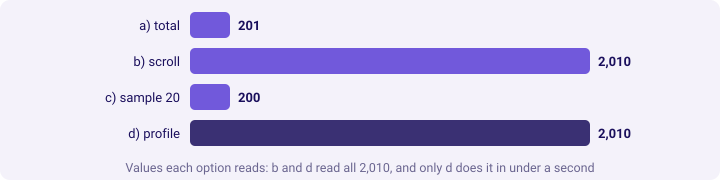

In [3]:
cells = len(raw) * len(FIELDS)
sizing = [
    ("a) total and compare", "201 amounts", "under a second", "stops on the first unreadable amount; says nothing about why"),
    ("b) scroll it", f"{cells:,} cells by eye", "about 17 minutes at half a second a cell", "repeats far apart are missed"),
    ("c) sample 20 rows", "20 rows", "about 10 minutes of tying out", f"the 20 rows it reads, and nothing about the other {len(raw) - 20}"),
    ("d) profile every field", f"{cells:,} values by code", "under a second", "finds every count that does not fit; the choice of copy waits"),
]
kit.table(["option", "what it reads", "time", "what it catches"], sizing,
          caption="Each option sized on this export: 201 rows, 10 fields")
kit.bars([("a) total", len(raw)), ("b) scroll", cells), ("c) sample 20", 20 * len(FIELDS)), ("d) profile", cells)],
         lit=(3,), title="Values each option reads: b and d read all 2,010, and only d does it in under a second")

**The best-fit call: d, then a sample where the profile points.** A profile reads every value in
under a second and turns each defect into a count that does not fit, and those counts are what a
reconciliation needs first. The minutes for b and c are illustrative: half a second a cell to
scroll and half a minute a row to tie out. **The fact that would change it:** a profile too slow
for the deadline, as on an export of crores of rows due in an hour. Then profile the key and the
money fields first, `order_id` and `amount`, read only the rows they flag, and let the other
fields wait.

## 2. What does the file hold, field by field?

The cell below first opens the export by the name a hurried analyst types from memory,
`orders.csv`, and meets a `FileNotFoundError`. An error like this gets two minutes: its last line
names the file Python looked for in the notebook's own folder, while the exports sit in
`../data/`, which `read_orders()` already knows. The cell then shows the first order as
`read_orders()` returns it and counts the rows in each segment and quarter. The export records four
customer segments: Retail-Core, Retail-Plus, Student, and Business, which is Kalpa's sales to
companies, every order in lakhs.

{'order_id': 'KR-02001', 'segment': 'Retail-Core', 'quarter': 'Q1', 'amount': '2200'}
the amount is held as str '2200'


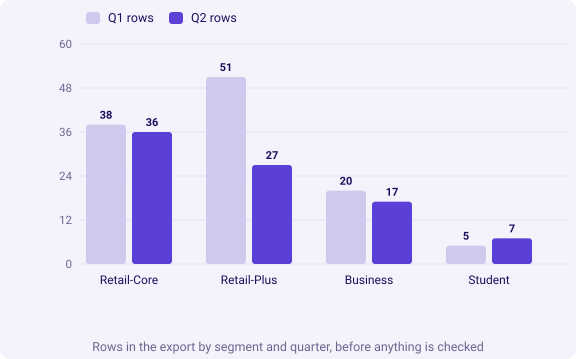

In [4]:
with kit.expect_error() as err:
    open("orders.csv")            # the name a hurried analyst types from memory

first = raw[0]
print({k: first[k] for k in ("order_id", "segment", "quarter", "amount")})
print("the amount is held as", type(first["amount"]).__name__, repr(first["amount"]))
segments = ["Retail-Core", "Retail-Plus", "Business", "Student"]
rows_by = {q: [sum(1 for r in raw if r["quarter"] == q and r["segment"] == s) for s in segments]
           for q in ("Q1", "Q2")}
kit.columns(segments, [("Q1 rows", rows_by["Q1"]), ("Q2 rows", rows_by["Q2"])],
            title="Rows in the export by segment and quarter, before anything is checked")

The file reads as 201 rows, and the first amount comes back as the text `'2200'`. A CSV holds only
text, so every value stays text until it is converted on purpose, and every sum, comparison and
sort on an amount depends on a conversion somebody chose. The profile asks each field three
questions: how many rows carry a value, how many of those convert to a number where the field
holds numbers, and how many are distinct.

**Predict before you run.** Which field falls furthest short of the 201 rows? a) `amount`, because
money fields are messy; b) `discount`, which Tuesday met as optional; c) `order_id`, because keys
have gaps; d) none, because an ERP export is complete.

field,present,convertible,distinct
order_id,201,text,186
customer_id,201,text,69
segment,201,text,4
channel,201,text,3
city,201,text,6
order_date,201,text,113
amount,201,200,161
status,200,text,3
quarter,201,text,2
discount,143,143,4


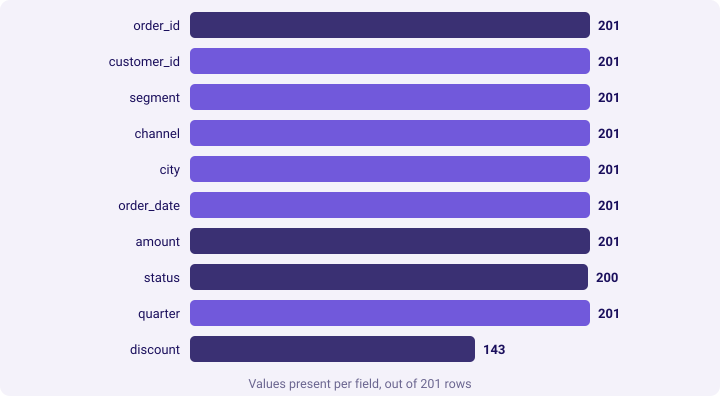

In [5]:
prof = profile(raw)
kit.table(["field", "present", "convertible", "distinct"],
          [(f, p["present"], p["convertible"] if f in NUMERIC else "text", p["distinct"])
           for f, p in prof.items()], caption="The profile of the orders CSV: 201 rows")
kit.bars([(f, prof[f]["present"]) for f in FIELDS], lit=(0, 6, 7, 9),
         title="Values present per field, out of 201 rows")

**What happened.** The answer is b: `discount` is present on 143 of 201 rows. Three smaller gaps
matter more to Anand. `order_id` is present on all 201 rows and distinct on 186, so some orders
appear more than once; `amount` is present on 201 and converts on 200; and `status` is present on
200. None of them is a total yet, and each is a question a later chapter answers.

In [6]:
kit.check("the export holds 201 rows", len(raw) == 201, f"{len(raw)}")
kit.check("every value arrives as text", all(isinstance(v, str) for r in raw for k, v in r.items() if k != "line"))
kit.check("the wrong name raised FileNotFoundError", err.name == "FileNotFoundError", err.name)
kit.check("order_id repeats: fewer distinct ids than rows", prof["order_id"]["distinct"] < len(raw),
          f'{prof["order_id"]["distinct"]} distinct of {len(raw)}')
kit.check("one amount does not convert", prof["amount"]["present"] - prof["amount"]["convertible"] == 1)
kit.check("status is missing on one row", len(raw) - prof["status"]["present"] == 1)

## 3. Which Q2 order is the largest?

Anand's analyst audits the way auditors do, the largest orders first, since one of them can carry
more rupees than a hundred small ones. A hurried analyst sorts Q2 by amount and sends her the top
three.

**The plausible wrong answer.**

In [7]:
q2 = [r for r in raw if r["quarter"] == "Q2"]
hurried_top = sorted(q2, key=lambda r: r["amount"], reverse=True)[:3]
kit.stats([(kit.rupees(int(hurried_top[0]["amount"])), "the largest Q2 order", "sorted as it was read"),
           (", ".join(r["amount"] for r in hurried_top), "the top three sent", "for the analyst to tie out"),
           ("0", "orders above Rs 10 lakh", "so the sample has no large order in it")],
          caption="The hurried sort, as it would be sent")

**Why it is wrong.** Text sorts character by character, so `'970'` beats `'2945460'` because `9`
comes after `2`. The analyst would tie out three small orders and skip the orders that carry the
quarter's money, and the audit would pass on the part of the file that matters least. The check
asks a business question: can the largest Q2 order be smaller than every Business order, when
Business sells in lakhs?

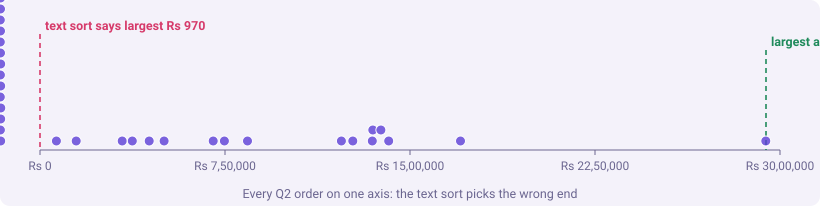

In [8]:
business_min = min(convert(r["amount"])[0] for r in raw if r["segment"] == "Business" and convert(r["amount"])[0])
kit.check("the text sort's largest order sits below the smallest Business order",
          int(hurried_top[0]["amount"]) < business_min, f"{hurried_top[0]['amount']} against {kit.rupees(business_min)}")
numeric_top = sorted((r for r in q2 if convert(r["amount"])[0]), key=lambda r: convert(r["amount"])[0], reverse=True)[:3]
kit.strip([convert(r["amount"])[0] for r in q2 if convert(r["amount"])[0]], lo=0, hi=3000000,
          markers=[("text sort says largest", int(hurried_top[0]["amount"]), "bad"),
                   ("largest as a number", convert(numeric_top[0]["amount"])[0], "good")],
          title="Every Q2 order on one axis: the text sort picks the wrong end")
kit.check("sorted as numbers, the largest Q2 order is above Rs 25 lakh", convert(numeric_top[0]["amount"])[0] > 2500000,
          kit.rupees(convert(numeric_top[0]["amount"])[0]))

**The fix, and what changed.** Convert before sorting. The largest Q2 order moves from Rs 970 to
Rs 29,45,460, and the top three now carry Rs 62,11,460 of the quarter's rupees instead of
Rs 9,53,940. Chapter 5 comes back to that largest order.

Kavya Nair, the senior analyst on the team, checks every number before it leaves.

> **Kavya's review.** "Any sort, max or comparison on an amount you have not converted is a sort
> on spelling. Convert once, at the door, and never again inside the analysis."

## 4. Does the dashboard's Rs 2.1 crore follow from this file?

The dashboard's figure is a total, so the test starts by totalling the amounts.

**Your turn, two minutes.** Type these lines into the empty cell and run them. The loop stops with
a `ValueError`; read the last line aloud and write down the value it names. The error gets its two
minutes, and the cells after it convert the same amounts on purpose.

```python
total = 0
for r in raw:
    total += int(r["amount"])
```

**Predict before you run.** `convert()` returns a number or a reason. After it runs on all 201
amounts, what should Q1 over the amounts that convert be? a) Rs 1,90,00,000, the books;
b) Rs 2,09,98,210, the dashboard's 2.1 crore; c) zero, since one failure stops the total;
d) something between the two.

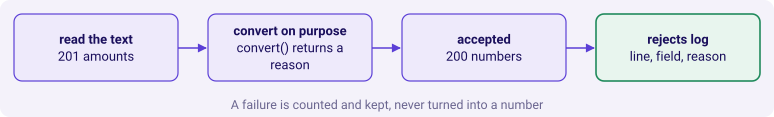

In [9]:
accepted, rejects = [], []
for r in raw:
    value, reason = convert(r["amount"])
    if value is None:
        rejects.append({"line": r["line"], "order_id": r["order_id"], "field": "amount", "reason": reason})
    else:
        accepted.append(dict(r, amount=value))
kit.stats([(f"{len(accepted)} + {len(rejects)}", "accepted and logged", f"of {len(raw)} rows"),
           (kit.rupees(Q(accepted, "Q1")), "Q1, amounts that convert", "the dashboard's 2.1 crore"),
           (kit.rupees(BOOKS_Q1), "Q1, the books", "Anand's 1.9 crore")])
kit.flow(["read the text\n201 amounts", "convert on purpose\nconvert() returns a reason",
          "accepted\n200 numbers", "rejects log\nline, field, reason"],
         kinds=[None, None, None, "good"], title="A failure is counted and kept, never turned into a number")
kit.check("accepted plus rejected is every row", len(accepted) + len(rejects) == len(raw), f"{len(accepted)} + {len(rejects)}")
kit.check("Q1 over the amounts that convert is the dashboard's figure", Q(accepted, "Q1") == 20998210)

**What happened.** The answer is b. The dashboard's 2.1 crore is honest arithmetic on this file:
Rs 2,09,98,210, which is Rs 19,98,210 above the books. The rejects log, the list of amounts that
failed with each one's file line and reason, holds one line, and the gap is a hundred times larger
than any one Retail order, so an unreadable amount cannot explain it. The repeated order ids can,
and chapter 2 weighs them.

## 5. What can the app's JSON feed tell us?

Read whole with `json.load`, the feed stops with a `JSONDecodeError`.

**Your turn, two minutes.** Type `json.load(open(DATA / "C2_W01_D03_orders_STUDENT.json"))` into the
empty cell, run it, read the line and column in the last line, and open the file there.

**Predict before you run.** The code below reads the feed one complete record at a time and stops
at the first that is not complete. How should the feed be used? a) in place of the CSV, as the
app's own record; b) as a witness to what the extract held, compared field by field; c) not at
all, since it fails to parse; d) merged into the CSV, so no order is lost between them.

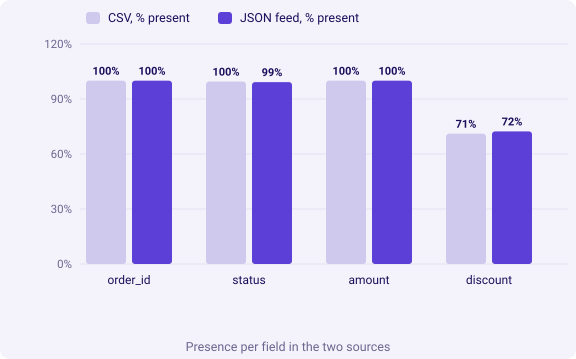

In [10]:
text = (DATA / "C2_W01_D03_orders_STUDENT.json").read_text(encoding="utf-8")
decoder, feed, at = json.JSONDecoder(), [], text.index("{")
while True:
    try:
        record, end = decoder.raw_decode(text, at)
    except json.JSONDecodeError:
        break                         # the first record that is not complete ends the read
    feed.append(record)
    at = text.find("{", end)
    if at == -1:
        break
feed_prof = profile(feed)
pct = lambda n, d: round(100 * n / d, 1)
shown = ("order_id", "status", "amount", "discount")
kit.columns(list(shown), [("CSV, % present", [pct(prof[f]["present"], len(raw)) for f in shown]),
                          ("JSON feed, % present", [pct(feed_prof[f]["present"], len(feed)) for f in shown])],
            fmt=lambda v: f"{v:.0f}%", title="Presence per field in the two sources")
csv_ids = {r["order_id"] for r in raw}
kit.check("the feed yields 119 complete records", len(feed) == 119, f"{len(feed)}")
kit.check("every feed record is an order the CSV holds", all(r["order_id"] in csv_ids for r in feed))

**What happened.** The answer is b. The feed yields 119 complete records, all orders the CSV holds.
It witnesses what the extract held, never whether a value is right: where the two agree, they
agree on what was exported, and a defect in the extract sits in both. It stops part way through,
so it cannot replace the CSV either. The two formats also record a missing value differently: a
CSV writes it as an empty string, while JSON leaves the key out, so `record["status"]` can raise
`KeyError` where the CSV returned `""`. The profile uses `.get(field, "")`, which counts both the
same way.

## 6. Do two other methods reach the same counts?

The profile counted distinct ids with a set and failures with `convert()`. A second route reaches
the same numbers with two methods that share none of that code: it sorts the ids and counts the
places where an id differs from the one before it, and it tests each amount against a pattern of
digits instead of asking `int()`. If the two routes disagree, one of them is wrong.

In [11]:
import re
ids_sorted = sorted(r["order_id"] for r in raw)
distinct_by_sort = 1 + sum(1 for a, b in zip(ids_sorted, ids_sorted[1:]) if a != b)
fail_by_pattern = sum(1 for r in raw if not re.fullmatch(r"[0-9]+", r["amount"]))
kit.table(["count", "the profile", "the second route", "how the second route counts"],
          [("distinct order ids", prof["order_id"]["distinct"], distinct_by_sort, "sorted ids, one more at each change"),
           ("rows beyond one per id", len(raw) - prof["order_id"]["distinct"], len(raw) - distinct_by_sort, "rows less the sorted count"),
           ("amounts that fail", prof["amount"]["present"] - prof["amount"]["convertible"], fail_by_pattern, "a pattern of digits, no int()")])
kit.check("both routes find 186 distinct ids", distinct_by_sort == prof["order_id"]["distinct"] == 186)
kit.check("both routes find one amount that fails",
          fail_by_pattern == prof["amount"]["present"] - prof["amount"]["convertible"] == 1)
kit.check("the rejects log agrees with the pattern", len(rejects) == fail_by_pattern)

count,the profile,the second route,how the second route counts
distinct order ids,186,186,"sorted ids, one more at each change"
rows beyond one per id,15,15,rows less the sorted count
amounts that fail,1,1,"a pattern of digits, no int()"


**When to switch.** The profile is the route for a first look, since it asks every field the same
three questions. The sort and the pattern are the routes to trust when the profile's own code is in
doubt, because they share none of it, so a slip in `convert()` or in a set cannot move them.
Chapter 2 goes one step further and keeps which rows share an id.

> **Kavya's review.** "Before you total anything, tell me how many records you received, how many
> are complete, how many convert and how many are distinct. A total from a file you have not
> profiled adds up whatever the file holds, repeated orders included."

### In the interview: where do you convert, and would you profile or sample 2 crore rows?

**[F] Everything read from a CSV is a string; what breaks and where do you convert?** "Arithmetic,
comparison and sorting break. Adding text to a number raises a TypeError; comparing `'970'` with
`'2945460'` puts 970 on top; `max` on text returns whatever starts with the highest digit. I
convert once, at the boundary, in one function that returns the value or the reason it failed,
and I count and log the failures. I never turn a failure into a default without writing that
decision down, because a zero is a claim about the business."

**[D] Design. A new export has 2 crore rows. Profile everything, or sample?** "Profile everything.
A profile is three counts per field, a few minutes of machine time, and it finds a defect wherever
it sits; a sample of 1,000 rows reads one row in 20,000 and says nothing about the rest. I would
sample only to read rows the profile has already pointed at. What would switch me is a profile too
slow for the deadline, and then I profile the key and the money fields first."

### Depth: should a conversion look before it leaps, or ask forgiveness?

Python offers two styles for a conversion. Look before you leap checks first, as `value.isdigit()`
does, and so refuses `" 950"`, an invented amount with a stray leading space that `int()` reads as
950 without complaint. Easier to ask forgiveness tries the conversion and handles the exception, as
`convert()` does, so the rule for a valid amount lives in one place. Real Python compares the two
(https://realpython.com/python-lbyl-vs-eafp/, verified 03 Sep 2026).

## So what did the ERP send, and does the dashboard's Rs 2.1 crore follow from it?

1. The way to learn what arrived is a profile of every field: 2,010 values in under a second, where
   scrolling takes about 17 minutes and a sample reads only 20 rows.
2. The file holds 201 rows with every value as text; `order_id` is distinct on 186, `amount`
   converts on 200, `status` is present on 200 and `discount` on 143.
3. The largest Q2 order is Rs 29,45,460 once amounts are numbers, and sorted as text the hurried
   answer is Rs 970.
4. The dashboard's figure does follow from the file: Q1 over the 200 amounts that convert is
   Rs 2,09,98,210, and the one failure sits in the rejects log.
5. The JSON feed shows what the extract held, 119 complete records that are all orders the CSV
   holds, and never whether a value is right.
6. Two other methods reach the same counts: the sorted ids count 186, and a digit pattern finds the
   one failure.

The ERP sent 201 rows for 186 order ids, with one amount that does not convert and one row with no
status. Q1 over the 200 amounts that convert is Rs 2,09,98,210, so the dashboard's 2.1 crore is
honest arithmetic on this file, and the 15 rows beyond one per order are the lead.

In [12]:
kit.table(["What chapter 1 established", "The number"],
          [("Rows the ERP sent in the orders CSV", "201"),
           ("Distinct order ids among them", "186"),
           ("Amounts that convert, and failures logged", "200 and 1"),
           ("Q1 over the amounts that convert", kit.rupees(Q(accepted, "Q1"))),
           ("Complete records in the JSON feed", str(len(feed)))], caption="The profile, before anyone reconciles")
kit.check_summary()
print("Next, chapter 2: the file holds 201 rows for 186 orders, so which rows did the export count "
      "twice, and what makes two rows one order?")

What chapter 1 established,The number
Rows the ERP sent in the orders CSV,201
Distinct order ids among them,186
"Amounts that convert, and failures logged",200 and 1
Q1 over the amounts that convert,"Rs 2,09,98,210"
Complete records in the JSON feed,119


Next, chapter 2: the file holds 201 rows for 186 orders, so which rows did the export count twice, and what makes two rows one order?
